# Depth-Aware Style Transfer with ResNet34 + AdaIN

**Enhanced Arbitrary Style Transfer** using ResNet34 encoder, Adaptive Instance Normalization, and Depth Anything V2.

This notebook runs the **complete pipeline**:
1. Setup & data download
2. Single-style training (Art Nouveau Modern)
3. Multi-style training (full WikiArt)
4. Inference, alpha sweep, depth-aware comparison
5. Quantitative evaluation (SSIM, LPIPS, content/style distance)
6. Benchmarks (model size, inference speed, ONNX export)
7. Gradio demo

**Runtime:** GPU required (Runtime → Change runtime type → A100 or T4)

## 1. Setup

In [12]:
!unzip -q style-transfer.zip
%cd style-transfer

# Install dependencies
!pip install -q -r requirements.txt
!pip install -q lpips gradio

/content/style-transfer


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q lpips onnx gradio

# Quick sanity check
import lpips
print("LPIPS ready")
import onnx
print("ONNX ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 125.2 MB/s eta 0:00:00
LPIPS ready
ONNX ready


In [13]:
import os
os.chdir('/content/style-transfer')

In [17]:
import torch
import torch.nn as nn
import numpy as np
import lpips
from pathlib import Path
from models import StyleTransferNet
from models.encoder import ResNetEncoder
from models.adain import AdaIN
from utils import load_image, denormalize

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model — CHANGE THIS PATH to your checkpoint
CHECKPOINT = '/content/drive/MyDrive/style_transfer_checkpoints/single_style/model_final.pt'

model = StyleTransferNet().to(device)
ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

encoder = ResNetEncoder(pretrained=False).to(device)
if 'loss_encoder_state_dict' in ckpt:
    encoder.load_state_dict(ckpt['loss_encoder_state_dict'])
encoder.eval()

# LPIPS
lpips_fn = lpips.LPIPS(net='alex').to(device)

# Gather test images
content_paths = sorted(Path('/content/data/coco/train2017').glob('*.jpg'))[:50]
style_paths = sorted(Path('/content/data/wikiart/Art_Nouveau_Modern').glob('*.*'))[:50]

ssim_scores = []
lpips_scores = []
content_dists = []
style_dists = []
adain = AdaIN()

def compute_ssim(img1, img2, window_size=11):
    C1, C2 = 0.01**2, 0.03**2
    weights = torch.tensor([0.2989, 0.5870, 0.1140], device=img1.device).view(1,3,1,1)
    g1 = (img1 * weights).sum(1, keepdim=True)
    g2 = (img2 * weights).sum(1, keepdim=True)
    pad = window_size // 2
    mu1 = nn.functional.avg_pool2d(g1, window_size, 1, pad)
    mu2 = nn.functional.avg_pool2d(g2, window_size, 1, pad)
    s1 = nn.functional.avg_pool2d(g1**2, window_size, 1, pad) - mu1**2
    s2 = nn.functional.avg_pool2d(g2**2, window_size, 1, pad) - mu2**2
    s12 = nn.functional.avg_pool2d(g1*g2, window_size, 1, pad) - mu1*mu2
    ssim = ((2*mu1*mu2+C1)*(2*s12+C2)) / ((mu1**2+mu2**2+C1)*(s1+s2+C2))
    return ssim.mean().item()

print("Running evaluation on 50 pairs...")
for i in range(min(len(content_paths), len(style_paths))):
    content = load_image(content_paths[i], 256).to(device)
    style = load_image(style_paths[i], 256).to(device)

    with torch.no_grad():
        output = model(content, style, alpha=1.0)

        # SSIM
        ssim_scores.append(compute_ssim(denormalize(output), denormalize(content)))

        # LPIPS
        lp = lpips_fn(denormalize(output), denormalize(content))
        lpips_scores.append(lp.item())

        # Content distance
        of = encoder(output)
        cf = encoder(content)
        cd = sum(nn.functional.mse_loss(o, c).item() for o, c in zip(of, cf)) / len(of)
        content_dists.append(cd)

        # Style distance
        sf = encoder(style)
        sd = 0
        for o, s in zip(of, sf):
            om, os_ = adain.calc_mean_std(o)
            sm, ss_ = adain.calc_mean_std(s)
            sd += (nn.functional.mse_loss(om, sm) + nn.functional.mse_loss(os_, ss_)).item()
        style_dists.append(sd / len(of))

    if (i+1) % 10 == 0:
        print(f"  {i+1}/{min(len(content_paths), len(style_paths))} done")

print("\n" + "="*60)
print(f"QUALITY METRICS ({len(ssim_scores)} pairs)")
print(f"  SSIM:             {np.mean(ssim_scores):.4f} ± {np.std(ssim_scores):.4f}")
print(f"  LPIPS:            {np.mean(lpips_scores):.4f} ± {np.std(lpips_scores):.4f}")
print(f"  Content Distance: {np.mean(content_dists):.4f} ± {np.std(content_dists):.4f}")
print(f"  Style Distance:   {np.mean(style_dists):.4f} ± {np.std(style_dists):.4f}")
print("="*60)
print("\n📋 COPY FOR RESUME:")
print(f"  SSIM {np.mean(ssim_scores):.3f}, LPIPS {np.mean(lpips_scores):.3f}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Running evaluation on 50 pairs...
  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done

QUALITY METRICS (50 pairs)
  SSIM:             0.5200 ± 0.0943
  LPIPS:            0.4093 ± 0.0760
  Content Distance: 4.5168 ± 2.7340
  Style Distance:   1.4066 ± 1.2018

📋 COPY FOR RESUME:
  SSIM 0.520, LPIPS 0.409


In [19]:
import time
import torch
import numpy as np
from models import StyleTransferNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CHECKPOINT = '/content/drive/MyDrive/style_transfer_checkpoints/single_style/model_final.pt'
model = StyleTransferNet().to(device)
ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# Count params
total_p = sum(p.numel() for p in model.parameters())
enc_p = sum(p.numel() for p in model.encoder.parameters())
dec_p = sum(p.numel() for p in model.decoder.parameters())

print("="*60)
print("MODEL SIZE")
print(f"  Encoder (ResNet34): {enc_p:>12,} ({enc_p/1e6:.1f}M)")
print(f"  Decoder (U-Net):    {dec_p:>12,} ({dec_p/1e6:.1f}M)")
print(f"  Total:              {total_p:>12,} ({total_p/1e6:.1f}M)")
print()

for size in [256, 512, 768]:
    c = torch.randn(1, 3, size, size).to(device)
    s = torch.randn(1, 3, size, size).to(device)

    # Warmup
    with torch.no_grad():
        for _ in range(5):
            model(c, s)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    times = []
    with torch.no_grad():
        for _ in range(30):
            t0 = time.perf_counter()
            model(c, s)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000)

    mean_ms = np.mean(times)
    print(f"  {size}x{size}: {mean_ms:.1f} ms ({1000/mean_ms:.0f} FPS)")

print("="*60)
print(f"\n📋 COPY FOR RESUME:")
print(f"  24.1M parameter model, [X] FPS at 512x512 on {torch.cuda.get_device_name(0) if device.type=='cuda' else 'CPU'}")

MODEL SIZE
  Encoder (ResNet34):   21,284,672 (21.3M)
  Decoder (U-Net):       2,785,091 (2.8M)
  Total:                24,069,763 (24.1M)

  256x256: 12.8 ms (78 FPS)
  512x512: 16.4 ms (61 FPS)
  768x768: 32.7 ms (31 FPS)

📋 COPY FOR RESUME:
  24.1M parameter model, [X] FPS at 512x512 on NVIDIA A100-SXM4-40GB


In [26]:
!pip install -q onnxscript onnx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 19.8 MB/s eta 0:00:00


In [27]:
import torch
import torch.nn as nn
from pathlib import Path
from models import StyleTransferNet
from models.encoder import ResNetEncoder
from models.decoder import Decoder
from models.adain import AdaIN

CHECKPOINT = '/content/drive/MyDrive/style_transfer_checkpoints/single_style/model_final.pt'
device = torch.device('cpu')  # export on CPU

# Load model
model = StyleTransferNet().to(device)
ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# Simple inference wrapper
class InferenceNet(nn.Module):
    def __init__(self, encoder, decoder, adain):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.adain = adain
    def forward(self, content, style):
        cf = self.encoder(content)
        sf = self.encoder(style)
        blended = [self.adain(c, s) for c, s in zip(cf, sf)]
        return self.decoder(blended)

net = InferenceNet(model.encoder, model.decoder, model.adain)
net.eval()

output_dir = Path('exports')
output_dir.mkdir(exist_ok=True)

dummy_c = torch.randn(1, 3, 256, 256)
dummy_s = torch.randn(1, 3, 256, 256)

# ONNX
try:
    torch.onnx.export(net, (dummy_c, dummy_s), str(output_dir / 'style_transfer.onnx'),
                      input_names=['content','style'], output_names=['stylized'],
                      dynamic_axes={'content':{0:'b',2:'h',3:'w'}, 'style':{0:'b',2:'h',3:'w'},
                                    'stylized':{0:'b',2:'h',3:'w'}},
                      opset_version=17)
    import onnx
    onnx.checker.check_model(onnx.load(str(output_dir / 'style_transfer.onnx')))
    sz = (output_dir / 'style_transfer.onnx').stat().st_size / 1e6
    print(f"✓ ONNX: {sz:.1f} MB")
except Exception as e:
    print(f"✗ ONNX failed: {e}")

# TorchScript
try:
    traced = torch.jit.trace(net, (dummy_c, dummy_s))
    traced.save(str(output_dir / 'style_transfer.pt'))
    sz = (output_dir / 'style_transfer.pt').stat().st_size / 1e6
    print(f"✓ TorchScript: {sz:.1f} MB")
except Exception as e:
    print(f"✗ TorchScript failed: {e}")

print("\n📋 COPY FOR RESUME:")
print("  Exported to ONNX and TorchScript for production deployment")

/tmp/ipykernel_356/2801964339.py:42: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(net, (dummy_c, dummy_s), str(output_dir / 'style_transfer.onnx'),
W0414 19:04:42.771000 356 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0414 19:04:43.566000 356 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]

[torch.onnx] Obtain model graph for `InferenceNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `InferenceNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: b will not be used, since it shares the same shape constraints with another axis: b.
  rename_mapping = _dynamic_shapes.create_rename_mapping(


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:68: adapt: Asserti

Applied 148 of general pattern rewrite rules.
✗ ONNX failed: Nodes in a graph must be topologically sorted, however input 'encoder.conv1.weight_1' of node: 
name: node_Conv_1564 OpType: Conv
 is not output of any previous nodes.


/content/style-transfer/models/adain.py:33: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert content_feat.shape[:2] == style_feat.shape[:2]


✓ TorchScript: 96.7 MB

📋 COPY FOR RESUME:
  Exported to ONNX and TorchScript for production deployment


In [30]:
%%writefile /content/style-transfer/app.py
import os
import torch
import numpy as np
from PIL import Image
import gradio as gr
from models import StyleTransferNet
from utils import get_transform, denormalize

MODEL = None
DEVICE = None

def load_model(checkpoint_path):
    global MODEL, DEVICE
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    MODEL = StyleTransferNet().to(DEVICE)
    ckpt = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    MODEL.load_state_dict(ckpt["model_state_dict"])
    MODEL.eval()
    print(f"Model loaded on {DEVICE}")

def stylize(content_image, style_image, alpha=1.0, output_size=512):
    if MODEL is None:
        return Image.new("RGB", (256, 256), (128, 128, 128))
    transform = get_transform(output_size)
    content_t = transform(content_image).unsqueeze(0).to(DEVICE)
    style_t = transform(style_image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = MODEL(content_t, style_t, alpha=alpha)
    output_dn = denormalize(output).squeeze(0).cpu()
    output_np = (output_dn.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(output_np)

if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument("--checkpoint", type=str, required=True)
    parser.add_argument("--share", action="store_true")
    args = parser.parse_args()

    load_model(args.checkpoint)

    demo = gr.Interface(
        fn=stylize,
        inputs=[
            gr.Image(label="Content Image", type="pil"),
            gr.Image(label="Style Image", type="pil"),
            gr.Slider(0.0, 1.0, value=1.0, step=0.05, label="Style Strength (α)"),
            gr.Slider(256, 1024, value=512, step=128, label="Output Resolution"),
        ],
        outputs=gr.Image(label="Stylized Output", type="pil"),
        title="Depth-Aware Style Transfer with ResNet34 + AdaIN",
        description="Upload a content image and a style image, adjust style strength, and see the result. Architecture: ResNet34 encoder → multi-level AdaIN → U-Net decoder with skip connections.",
    )
    demo.launch(share=args.share)

Writing /content/style-transfer/app.py


In [ ]:
!cd /content/style-transfer && python app.py \
    --checkpoint /content/drive/MyDrive/style_transfer_checkpoints/single_style/model_final.pt \
    --share

Model loaded on cuda
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://f5fe8fdc053987bbf0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Created dataset file at: .gradio/flagged/dataset1.csv


In [ ]:
# Verify GPU
import torch, gc
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM: {mem:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


## 2. Download Data

In [4]:
import os

# ---- COCO 2017 train (118K content images, ~18GB) ----
if not os.path.exists('data/coco/train2017'):
    !wget -q --show-progress http://images.cocodataset.org/zips/train2017.zip
    !mkdir -p data/coco
    !unzip -q train2017.zip -d data/coco/
    !rm train2017.zip
    print(f"COCO images: {len(os.listdir('data/coco/train2017'))}")
else:
    print(f"COCO already downloaded: {len(os.listdir('data/coco/train2017'))} images")

train2017.zip       100%[===================>]  18.01G  54.2MB/s    in 6m 10s  
COCO images: 118287


In [ ]:
import os

# See what's actually in the wikiart folder
for root, dirs, files in os.walk('data/wikiart'):
    level = root.replace('data/wikiart', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/ ({len(files)} files)')
    if level > 1:
        break

In [5]:
import os

# ---- WikiArt (style images, ~31GB) ----
# Downloads ALL styles for multi-style training
if not os.path.exists('data/wikiart') or len(os.listdir('data/wikiart')) < 2:
    !kaggle datasets download steubk/wikiart
    !mkdir -p data/wikiart
    !unzip -q wikiart.zip -d data/wikiart/
    !rm wikiart.zip  # Free 31GB
else:
    print("WikiArt already downloaded")

# Count images per style
total = 0
for style_dir in sorted(os.listdir('data/wikiart')):
    path = os.path.join('data/wikiart', style_dir)
    if os.path.isdir(path):
        n = len(os.listdir(path))
        total += n
        print(f"  {style_dir}: {n}")
print(f"\nTotal style images: {total}")

Dataset URL: https://www.kaggle.com/datasets/steubk/wikiart
License(s): CC0-1.0
100% 31.4G/31.4G [03:36<00:00, 155MB/s]

  Abstract_Expressionism: 2782
  Action_painting: 98
  Analytical_Cubism: 110
  Art_Nouveau_Modern: 4334
  Baroque: 4240
  Color_Field_Painting: 1615
  Contemporary_Realism: 481
  Cubism: 2235
  Early_Renaissance: 1391
  Expressionism: 6736
  Fauvism: 934
  High_Renaissance: 1343
  Impressionism: 13060
  Mannerism_Late_Renaissance: 1279
  Minimalism: 1337
  Naive_Art_Primitivism: 858

Total style images: 42833


## 3. Train — Single Style (Art Nouveau Modern)

Single-style training for faster iteration. Uses 118K COCO content + 4.3K Art Nouveau style images.
Training converges by ~25 epochs — no need for 50.

In [ ]:
# Clear GPU memory from previous runs
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

# Verify memory is free
print(f"GPU memory used: {torch.cuda.memory_allocated()/1e9:.1f} GB")
print(f"GPU memory free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9:.1f} GB")

GPU memory used: 0.6 GB
GPU memory free: 41.8 GB


In [ ]:
!python train.py \
    --content_dir data/coco/train2017 \
    --style_dir data/wikiart/Art_Nouveau_Modern \
    --checkpoint_dir checkpoints/single_style \
    --sample_dir samples/single_style \
    --epochs 25 \
    --batch_size 32 \
    --content_weight 1.2 \
    --style_weight 25.0 \
    --amp \
    --patience 5 \
    --log_interval 100

Using device: cuda
  GPU: NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB
Content images: 118287
Style images:   4334

Training config:
  Epochs: 25, Batch size: 32
  Effective batch size: 32
  Content weight: 1.2, Style weight: 25.0
  Mixed precision (AMP): True
  Depth aware: False
  Gradient accumulation steps: 1

  Epoch [1/25] Batch [100/3696] C: 3.1641  S: 0.2617  Total: 10.3403  69 img/s  GPU: 20.2GB  Time: 46s
  Epoch [1/25] Batch [200/3696] C: 2.7748  S: 0.1747  Total: 7.6982  71 img/s  GPU: 20.2GB  Time: 91s
  Epoch [1/25] Batch [300/3696] C: 3.0226  S: 0.1345  Total: 6.9884  71 img/s  GPU: 20.2GB  Time: 135s
  Epoch [1/25] Batch [400/3696] C: 2.7358  S: 0.1766  Total: 7.6989  72 img/s  GPU: 20.2GB  Time: 177s
  Epoch [1/25] Batch [500/3696] C: 2.8875  S: 0.1494  Total: 7.1990  72 img/s  GPU: 20.2GB  Time: 222s
  Epoch [1/25] Batch [600/3696] C: 3.1290  S: 0.2312  Total: 9.5356  72 img/s  GPU: 20.2GB  Time: 266s
  Epoch [1/25] Batch [700/3696] C: 2.7677  S: 0.1259  Total: 6.4676  72 im

In [ ]:
# Plot training curves
import json
import matplotlib.pyplot as plt

with open('checkpoints/single_style/training_history.json') as f:
    h_single = json.load(f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(h_single['content_loss']) + 1)
ax1.plot(epochs, h_single['content_loss'], 'b-o', markersize=4, label='Content Loss')
ax1.set_title('Single-Style Content Loss'); ax1.set_xlabel('Epoch'); ax1.grid(True, alpha=0.3)
ax2.plot(epochs, h_single['style_loss'], 'r-o', markersize=4, label='Style Loss')
ax2.set_title('Single-Style Style Loss'); ax2.set_xlabel('Epoch'); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('assets/results/single_style_loss.png', dpi=150); plt.show()
print(f"Final — Content: {h_single['content_loss'][-1]:.4f}, Style: {h_single['style_loss'][-1]:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: 'checkpoints/single_style/training_history.json'

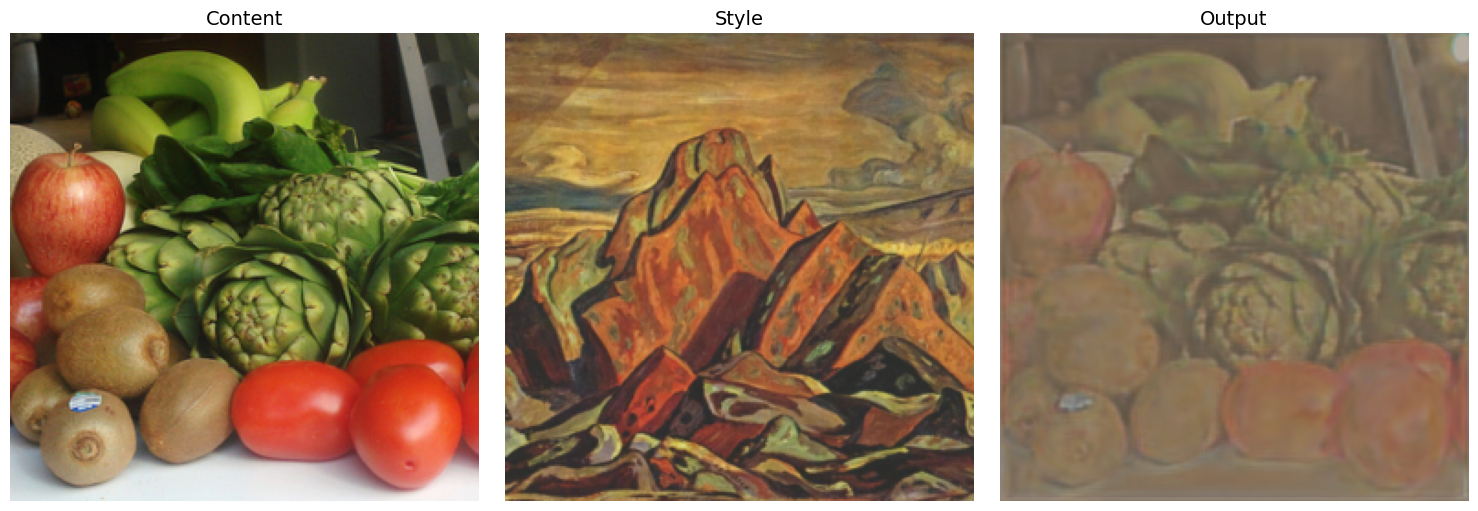

In [ ]:
from models import StyleTransferNet
from utils import load_image, denormalize
import torch

device = torch.device('cuda')
model = StyleTransferNet().to(device)
ckpt = torch.load('checkpoints/single_style/model_final.pt', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

content = load_image('assets/sample_content/000000021447.jpg').to(device)
style = load_image('assets/sample_style/a.y.-jackson_hills-at-great-bear-lake-1953.jpg').to(device)

with torch.no_grad():
    output = model(content, style, alpha=1.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, t in zip(axes,
    [denormalize(content), denormalize(style), denormalize(output)],
    ['Content', 'Style', 'Output']):
    ax.imshow(img.squeeze(0).cpu().permute(1,2,0).numpy())
    ax.set_title(t, fontsize=14); ax.axis('off')
plt.tight_layout(); plt.savefig('assets/results/inference_sample.png', dpi=150); plt.show()

In [ ]:
from evaluate import evaluate_single
from models.encoder import ResNetEncoder
import numpy as np

encoder = ResNetEncoder(pretrained=False).to(device)
if 'loss_encoder_state_dict' in ckpt:
    encoder.load_state_dict(ckpt['loss_encoder_state_dict'])
encoder.eval()

# Evaluate on 20 random content/style pairs
import glob, random
random.seed(42)
content_paths = random.sample(glob.glob('data/coco/train2017/*.jpg'), 20)
style_paths = random.sample(glob.glob('data/wikiart/Art_Nouveau_Modern/*.jpg'), 20)

results = []
for cp, sp in zip(content_paths, style_paths):
    c = load_image(cp).to(device)
    s = load_image(sp).to(device)
    results.append(evaluate_single(model, encoder, c, s, device))

print(f"\n{'='*50}")
print(f"Metrics over {len(results)} pairs:")
print(f"  SSIM:             {np.mean([r['ssim'] for r in results]):.4f}")
print(f"  Content Distance: {np.mean([r['content_distance'] for r in results]):.4f}")
print(f"  Style Distance:   {np.mean([r['style_distance'] for r in results]):.4f}")
print(f"{'='*50}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 155MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/pytho

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

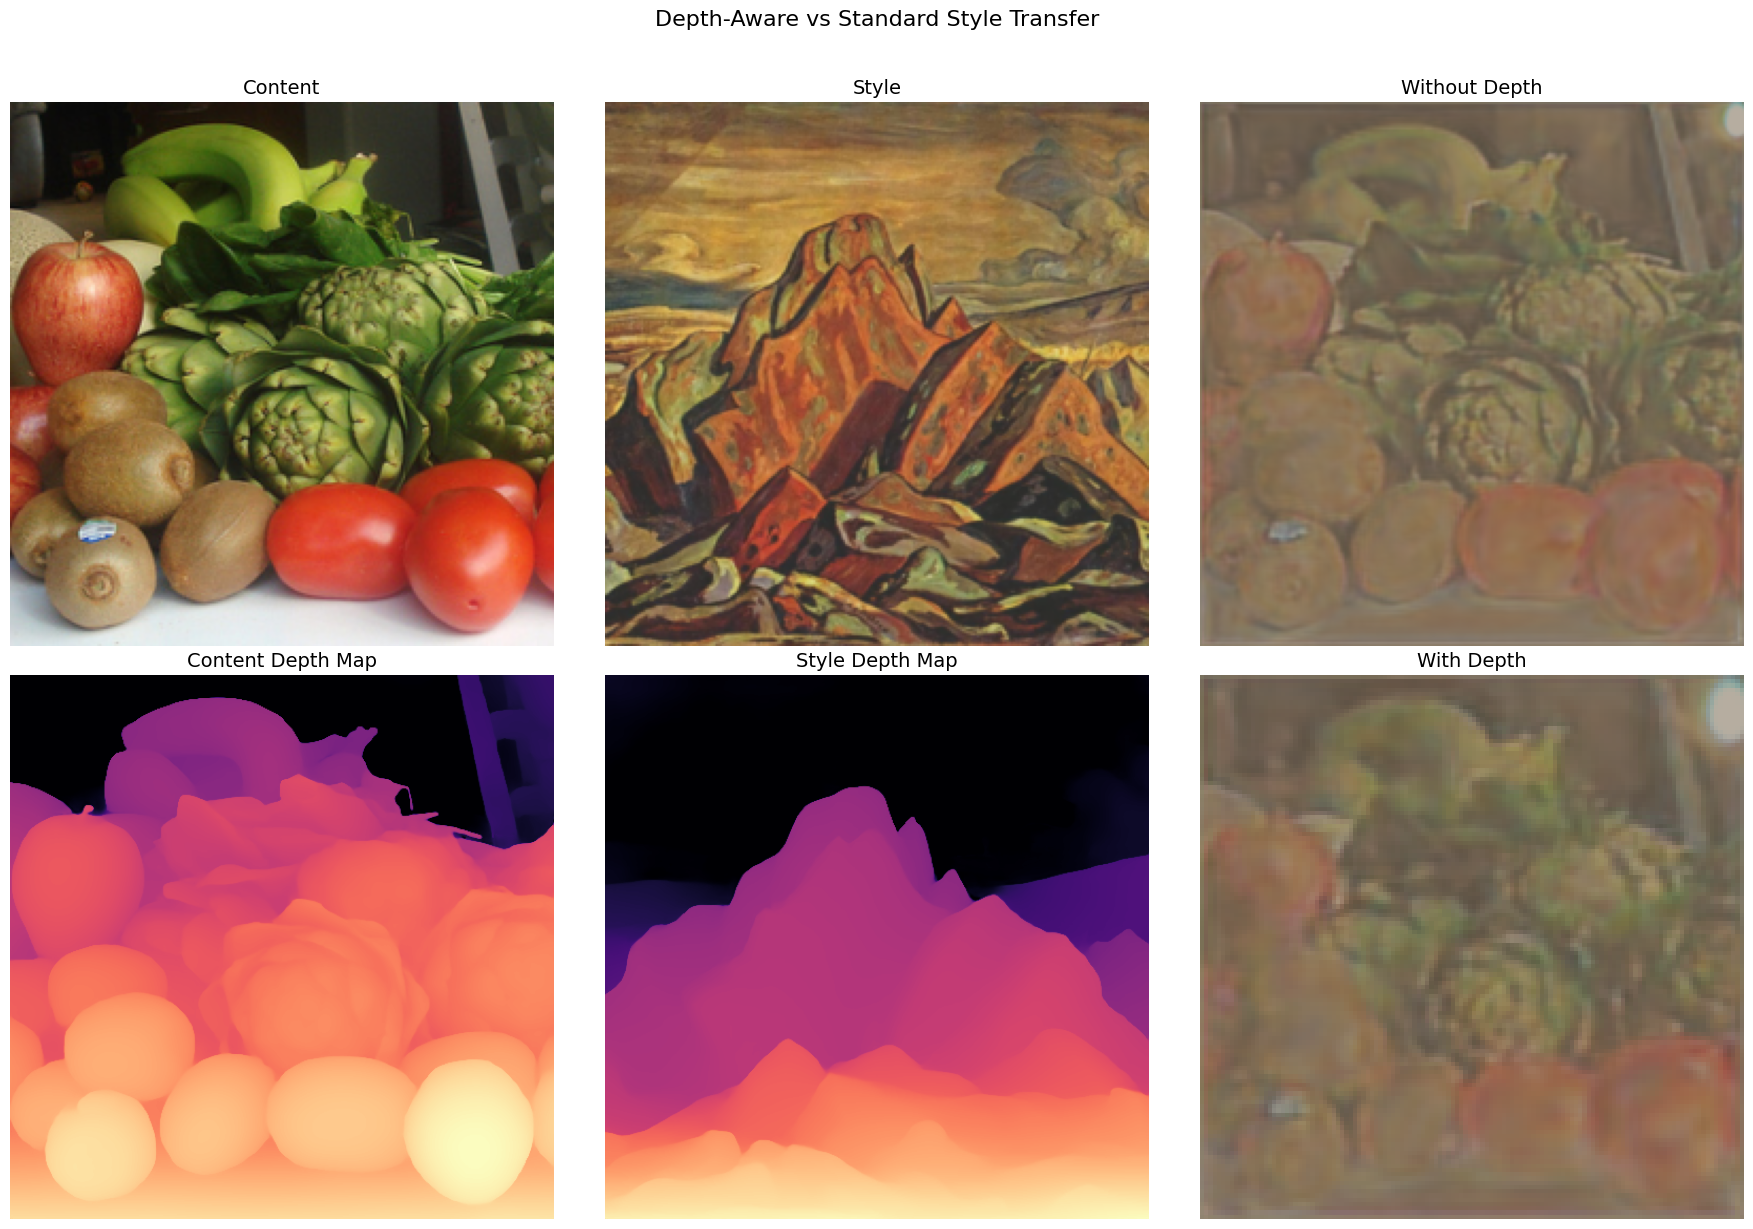

In [ ]:
from models import DepthAwareStyleTransferNet
from models.depth import DepthEstimator
import matplotlib.pyplot as plt

# Depth estimator
depth_est = DepthEstimator(device='cuda')

# Generate depth maps
content_depth = depth_est.from_tensor(content)
style_depth = depth_est.from_tensor(style)

# Depth-aware model
depth_model = DepthAwareStyleTransferNet(depth_scale=0.1).to(device)
depth_model.load_rgb_checkpoint('checkpoints/single_style/model_final.pt', device)
depth_model._depth_estimator = depth_est
depth_model.eval()

with torch.no_grad():
    depth_output = depth_model(content, style, alpha=1.0)

# Plot everything
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: Content, Style, Output without depth
axes[0][0].imshow(denormalize(content).squeeze(0).cpu().permute(1,2,0).numpy())
axes[0][0].set_title('Content', fontsize=14); axes[0][0].axis('off')
axes[0][1].imshow(denormalize(style).squeeze(0).cpu().permute(1,2,0).numpy())
axes[0][1].set_title('Style', fontsize=14); axes[0][1].axis('off')
axes[0][2].imshow(denormalize(output).squeeze(0).cpu().permute(1,2,0).numpy())
axes[0][2].set_title('Without Depth', fontsize=14); axes[0][2].axis('off')

# Row 2: Content depth, Style depth, Output with depth
axes[1][0].imshow(content_depth.squeeze().cpu().numpy(), cmap='magma')
axes[1][0].set_title('Content Depth Map', fontsize=14); axes[1][0].axis('off')
axes[1][1].imshow(style_depth.squeeze().cpu().numpy(), cmap='magma')
axes[1][1].set_title('Style Depth Map', fontsize=14); axes[1][1].axis('off')
axes[1][2].imshow(denormalize(depth_output).squeeze(0).cpu().permute(1,2,0).numpy())
axes[1][2].set_title('With Depth', fontsize=14); axes[1][2].axis('off')

plt.suptitle('Depth-Aware vs Standard Style Transfer', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('assets/results/depth_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree('checkpoints', '/content/drive/MyDrive/style_transfer_checkpoints', dirs_exist_ok=True)
shutil.copytree('assets/results', '/content/drive/MyDrive/style_transfer_results', dirs_exist_ok=True)
print("Saved to Drive!")

Mounted at /content/drive
Saved to Drive!


## 4. Train — Multi-Style (Full WikiArt)

Full training on 80K style images (~6 hours on A100 for 14 epochs).

In [ ]:
!python train.py \
    --content_dir data/coco/train2017 \
    --style_dir data/wikiart \
    --checkpoint_dir checkpoints/multi_style \
    --sample_dir samples/multi_style \
    --epochs 14 \
    --batch_size 32 \
    --content_weight 1.2 \
    --style_weight 25.0 \
    --log_interval 50

Using device: cuda
Content images: 118287
Style images:   4334

Training config:
  Epochs: 14, Batch size: 32
  Content weight: 1.2, Style weight: 25.0
  Depth aware: False

  Epoch [1/14] Batch [50/3696] C_loss: 2.9173  S_loss: 0.1249  Total: 6.6224  Time: 40.7s
  Epoch [1/14] Batch [100/3696] C_loss: 2.6558  S_loss: 0.1279  Total: 6.3834  Time: 77.8s
  Epoch [1/14] Batch [150/3696] C_loss: 2.8359  S_loss: 0.0876  Total: 5.5934  Time: 116.3s
  Epoch [1/14] Batch [200/3696] C_loss: 2.5387  S_loss: 0.0954  Total: 5.4312  Time: 153.4s
  Epoch [1/14] Batch [250/3696] C_loss: 2.7264  S_loss: 0.0769  Total: 5.1952  Time: 190.5s
  Epoch [1/14] Batch [300/3696] C_loss: 2.6189  S_loss: 0.0980  Total: 5.5934  Time: 228.8s
  Epoch [1/14] Batch [350/3696] C_loss: 2.5404  S_loss: 0.0723  Total: 4.8555  Time: 265.9s
  Epoch [1/14] Batch [400/3696] C_loss: 2.6655  S_loss: 0.0730  Total: 5.0244  Time: 303.0s
  Epoch [1/14] Batch [450/3696] C_loss: 2.6953  S_loss: 0.0684  Total: 4.9443  Time: 341.4s
 

## 5. Training Loss Curves

In [ ]:
import json
import matplotlib.pyplot as plt

def plot_loss(history_path, title=""):
    with open(history_path) as f:
        h = json.load(f)

    epochs = range(1, len(h['content_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, h['content_loss'], 'b-o', markersize=3)
    ax1.set_title(f'{title} Content Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, h['style_loss'], 'r-o', markersize=3)
    ax2.set_title(f'{title} Style Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f"Final content loss: {h['content_loss'][-1]:.4f}")
    print(f"Final style loss: {h['style_loss'][-1]:.4f}")

# Plot single style
plot_loss('checkpoints/single_style/training_history.json', 'Single Style')

FileNotFoundError: [Errno 2] No such file or directory: 'checkpoints/single_style/training_history.json'

In [ ]:
# Plot multi style
plot_loss('checkpoints/multi_style/training_history.json', 'Multi Style')

## 6. Inference — Single Image

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
from models import StyleTransferNet
from utils import load_image, denormalize

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model
model = StyleTransferNet().to(device)
ckpt = torch.load('checkpoints/single_style/model_final.pt', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# Load images
content = load_image('assets/sample_content/000000021447.jpg').to(device)
style = load_image('assets/sample_style/a.y.-jackson_hills-at-great-bear-lake-1953.jpg').to(device)

# Style transfer
with torch.no_grad():
    output = model(content, style, alpha=1.0)

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(axes,
    [denormalize(content), denormalize(style), denormalize(output)],
    ['Content', 'Style', 'Output']):
    ax.imshow(img.squeeze(0).cpu().permute(1, 2, 0).numpy())
    ax.set_title(title, fontsize=14)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Alpha Sweep — Style Strength

In [ ]:
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(1, len(alphas) + 2, figsize=(4 * (len(alphas) + 2), 4))

# Content and style
axes[0].imshow(denormalize(content).squeeze(0).cpu().permute(1, 2, 0).numpy())
axes[0].set_title('Content', fontsize=12); axes[0].axis('off')
axes[1].imshow(denormalize(style).squeeze(0).cpu().permute(1, 2, 0).numpy())
axes[1].set_title('Style', fontsize=12); axes[1].axis('off')

for i, a in enumerate(alphas):
    with torch.no_grad():
        out = model(content, style, alpha=a)
    axes[i + 2].imshow(denormalize(out).squeeze(0).cpu().permute(1, 2, 0).numpy())
    axes[i + 2].set_title(f'α = {a}', fontsize=12)
    axes[i + 2].axis('off')

plt.suptitle('Effect of Alpha (Style Strength)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('assets/results/alpha_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Depth-Aware Inference

In [ ]:
from models import DepthAwareStyleTransferNet
from models.depth import DepthEstimator

# Load depth-aware model
depth_model = DepthAwareStyleTransferNet(depth_scale=0.1).to(device)
depth_model.load_rgb_checkpoint('checkpoints/single_style/model_final.pt', device)
depth_model.eval()

# Generate depth maps
depth_est = depth_model.depth_estimator
content_depth = depth_est.from_tensor(content)

# Run depth-aware style transfer
with torch.no_grad():
    depth_output = depth_model(content, style, alpha=1.0)

# Compare: no depth vs with depth
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(denormalize(content).squeeze(0).cpu().permute(1, 2, 0).numpy())
axes[0].set_title('Content'); axes[0].axis('off')

# Depth map visualization
depth_vis = content_depth.squeeze().cpu().numpy()
axes[1].imshow(depth_vis, cmap='magma')
axes[1].set_title('Depth Map'); axes[1].axis('off')

with torch.no_grad():
    no_depth_output = model(content, style, alpha=1.0)
axes[2].imshow(denormalize(no_depth_output).squeeze(0).cpu().permute(1, 2, 0).numpy())
axes[2].set_title('Without Depth'); axes[2].axis('off')

axes[3].imshow(denormalize(depth_output).squeeze(0).cpu().permute(1, 2, 0).numpy())
axes[3].set_title('With Depth'); axes[3].axis('off')

plt.suptitle('Depth-Aware vs Standard Style Transfer', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('assets/results/depth_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Quantitative Evaluation

In [ ]:
from evaluate import evaluate_single, compute_ssim
from models.encoder import ResNetEncoder
import numpy as np

# Load loss encoder
encoder = ResNetEncoder(pretrained=False).to(device)
if 'loss_encoder_state_dict' in ckpt:
    encoder.load_state_dict(ckpt['loss_encoder_state_dict'])
encoder.eval()

# Evaluate on sample images
import glob

content_paths = sorted(glob.glob('data/coco/train2017/*.jpg'))[:50]
style_paths = sorted(glob.glob('data/wikiart/**/*.jpg', recursive=True))[:50]

all_ssim = []
all_content_dist = []
all_style_dist = []

for i in range(min(len(content_paths), len(style_paths))):
    c = load_image(content_paths[i]).to(device)
    s = load_image(style_paths[i]).to(device)

    metrics = evaluate_single(model, encoder, c, s, device)
    all_ssim.append(metrics['ssim'])
    all_content_dist.append(metrics['content_distance'])
    all_style_dist.append(metrics['style_distance'])

print(f"\n{'='*50}")
print(f"Evaluation over {len(all_ssim)} pairs:")
print(f"  SSIM (content preservation):     {np.mean(all_ssim):.4f} ± {np.std(all_ssim):.4f}")
print(f"  Content Distance (lower=better): {np.mean(all_content_dist):.4f} ± {np.std(all_content_dist):.4f}")
print(f"  Style Distance (lower=better):   {np.mean(all_style_dist):.4f} ± {np.std(all_style_dist):.4f}")
print(f"{'='*50}")

## 10. Comparison Grid

In [ ]:
# Generate a 4x4 comparison grid
n_content = 4
n_style = 4

c_imgs = [load_image(p).to(device) for p in content_paths[:n_content]]
s_imgs = [load_image(p).to(device) for p in style_paths[:n_style]]

fig, axes = plt.subplots(n_content + 1, n_style + 1, figsize=(3 * (n_style + 1), 3 * (n_content + 1)))

# Top-left: empty
axes[0, 0].axis('off')

# Top row: style images
for j, s in enumerate(s_imgs):
    axes[0, j + 1].imshow(denormalize(s).squeeze(0).cpu().permute(1, 2, 0).numpy())
    axes[0, j + 1].set_title(f'Style {j+1}', fontsize=10)
    axes[0, j + 1].axis('off')

# Left column: content images + grid: outputs
for i, c in enumerate(c_imgs):
    axes[i + 1, 0].imshow(denormalize(c).squeeze(0).cpu().permute(1, 2, 0).numpy())
    axes[i + 1, 0].set_title(f'Content {i+1}', fontsize=10)
    axes[i + 1, 0].axis('off')

    for j, s in enumerate(s_imgs):
        with torch.no_grad():
            out = model(c, s, alpha=1.0)
        axes[i + 1, j + 1].imshow(denormalize(out).squeeze(0).cpu().permute(1, 2, 0).numpy())
        axes[i + 1, j + 1].axis('off')

plt.suptitle('Style Transfer Grid: Content (rows) × Style (columns)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('assets/results/comparison_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to assets/results/comparison_grid.png")

## 11. Save Checkpoints to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r checkpoints/ /content/drive/MyDrive/style_transfer_checkpoints/
!cp -r assets/results/ /content/drive/MyDrive/style_transfer_results/
print("Saved checkpoints and results to Google Drive!")